## Text input

https://platform.openai.com/docs/models

In [19]:
from dotenv import load_dotenv


load_dotenv(override=True)

True

In [13]:
from langchain.agents import create_agent

agent = create_agent(
    model='groq:openai/gpt-oss-20b',
    system_prompt="You are a science fiction writer, create a story at the users request.",
)

In [14]:
from langchain.messages import HumanMessage

question = HumanMessage(content=[
    {"type": "text", "text": "What is the capital of The Moon?"}
])

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

The Moon doesn’t have a capital. It’s a natural satellite of Earth with no permanent government, administrative center, or official “capital” city. If you’re thinking of a fictional setting where the Moon has its own state, that would be a creative choice made by that story’s author, not a real-world fact.


## Image input

In [11]:
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(accept='.png ,.jpg', multiple=False)
display(uploader)

FileUpload(value=(), accept='.png ,.jpg', description='Upload')

In [12]:
print(uploader.value)

({'name': 'Cinematic edit _ Judy Hopps _ 4K.jpg', 'type': 'image/jpeg', 'size': 61341, 'content': <memory at 0x00000286FFBF5240>, 'last_modified': datetime.datetime(2026, 9, 2, 17, 40, 54, 889000, tzinfo=datetime.timezone.utc)},)


In [13]:
import base64 #represents the image by   base64 module
# Get the first (and only) uploaded file dict
uploaded_file = uploader.value[0]

# This is a memoryview
content_mv = uploaded_file["content"]

# Convert memoryview -> bytes
img_bytes = bytes(content_mv)  # or content_mv.tobytes()

# Now base64 encode
img_b64 = base64.b64encode(img_bytes).decode("utf-8")

In [43]:
import os
from langchain.chat_models import init_chat_model

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") 
model = init_chat_model(
    model="gemini-3.6-flash",
    model_provider="google_genai",
    api_key=GOOGLE_API_KEY,
    temperature=1.0
)

In [ ]:
import os
print(repr(os.getenv("GOOGLE_API_KEY")))

In [31]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model = init_chat_model(
    model="gemini-3.6-flash",
    model_provider="google_genai",
    api_key=GOOGLE_API_KEY,
    temperature=1.0
),
    checkpointer=InMemorySaver()
)

multimodal_question = {
    "role": "user",
    "content": [
        {"type": "text", "text": "Tell me about this image and what it represents."},
        {
            "type": "image",
            "source_type": "base64",
            "data": img_b64,
            "mime_type": "image/png"
        }
    ]
}
config = {"configurable": {"thread_id": "1"}}

response = agent.invoke(
    {"messages": [multimodal_question]},
    config
)

d:\NTI\LLMs\LearnLangChain\Introduction to LangChain Course 1\IntroductionLangChain\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [35]:
from pprint import pprint
pprint(response['messages'])

[HumanMessage(content=[{'type': 'text', 'text': 'Tell me about this image and what it represents.'}, {'type': 'image', 'source_type': 'base64', 'data': '...', 'mime_type': 'image/png'}], additional_kwargs={}, response_metadata={}, id='493cedd2-ac59-462c-b2c4-5974d754ce35'),
 AIMessage(content=[{'type': 'text', 'text': '### **Overview**\nThis image features **Officer Judy Hopps**, the main protagonist of Disney’s 2016 animated film ***Zootopia***. \n\nIn this scene, Judy is wearing her official Zootopia Police Department (ZPD) uniform—complete with her bulletproof vest, badge, duty belt, and arm guards—while resting her paws on a high wooden desk.\n\n---\n\n### **Context & Scene Details**\n* **Character:** Judy Hopps, an ambitious, optimistic European rabbit who moves from her rural hometown (Bunnyburrow) to the bustling metropolis of Zootopia to become the city\'s very first rabbit police officer.\n* **Setting:** Inside the Zootopia Police Department headquarters. The desk she is leani

## Audio input

In [37]:
import sounddevice as sd
from scipy.io.wavfile import write
import base64
import io
import time
from tqdm import tqdm

# Recording settings
duration = 5  # seconds
sample_rate = 44100

print("Recording...")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
# Progress bar for the duration
for _ in tqdm(range(duration * 10)):   # update 10× per second
    time.sleep(0.1)
sd.wait()
print("Done.")

# Write WAV to an in-memory buffer
buf = io.BytesIO()
write(buf, sample_rate, audio)
wav_bytes = buf.getvalue()

aud_b64 = base64.b64encode(wav_bytes).decode("utf-8")

Recording...


100%|██████████| 50/50 [00:05<00:00,  9.84it/s]


Done.


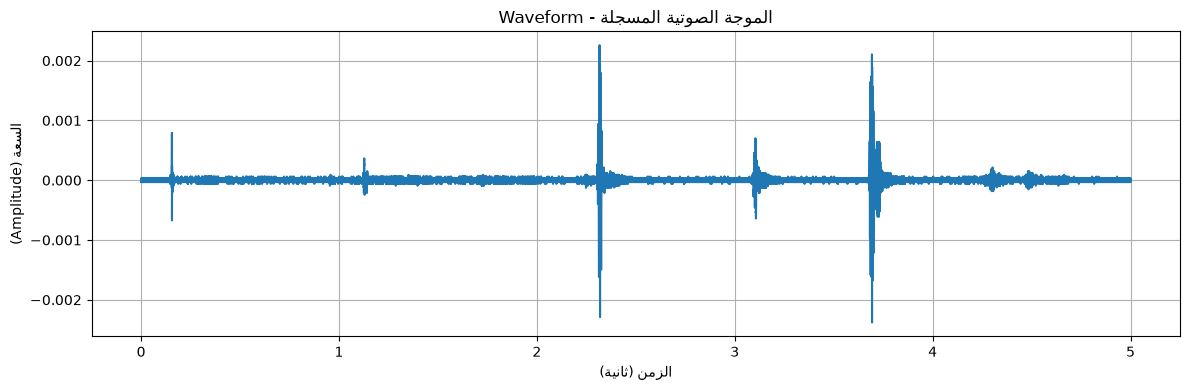

In [39]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.linspace(0, duration, num=len(audio))

plt.figure(figsize=(12, 4))
plt.plot(time_axis, audio)
plt.title("Waveform - الموجة الصوتية المسجلة")
plt.xlabel("الزمن (ثانية)")
plt.ylabel("السعة (Amplitude)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import os
from langchain.chat_models import init_chat_model

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") 
model = init_chat_model(
    model="gemini-3.6-flash",
    model_provider="google_genai",
    api_key=GOOGLE_API_KEY,
    temperature=1.0
)

In [44]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
agent = create_agent(
    model,
)

multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this audio file"},
    {"type": "audio", "base64": aud_b64, "mime_type": "audio/wav"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)

d:\NTI\LLMs\LearnLangChain\Introduction to LangChain Course 1\IntroductionLangChain\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The audio features a short, clear recording of someone whistling a brief melody for about four seconds.', 'extras': {'signature': 'EqIFCp8FARFNMg9E+9As8voXV7Qw9Szh8SlkwF+Wy6ogomR4IDlibWPserjTy3iDfBZMFzZCdFkkERdiYB4MQtpi/IxjK32v6O8IS7RycMTIbErLnnwWpjMVmELNlKqolC2QojGVBw44KkSJA6HUMNZ722OC4YMrOzWNMt7xQK+LlD7tIPxqRFQWB0WeFHzBKkYAJQtk9Md7dg21xMAgEfHz6v1CjxFdnysDYmuEziWfcGUDSeaFbMo1KEIooUfHgRr+UNKlzZNaakoW9npQYEhyP8gASSW+X4waqcp9rnWccb52SkeRjltrhXUEKD131MrdqueeTgC3AGQlIBzk95ndZI9OXt5Zspda9A4SQ9P4cjVbpb5rxPaD410cUB72exOD+o8+fuJECsB0Lg5K9Bjh8wy1+JELFuuJfdfgOLgNuf9EvsTXukwj6XH4eFzciTUw7sFrYMsjpsrq8qKzfAgzIqOC0C8FpePnZ7/kRr9TkIumSU4mm2tf0nd9Pw2mcq3cchJoIR+cgNT+NBu4tj7apQ+ua7hKV48Ol3SvdhiOM36vBd2Ozwa7D1fB9+EMTZfP+4oNdwbLoYb1L21+/RP2Akp/qV36sV+mCDG0QfWgkBvuVzl0s0zRjJKYpq5wGd+xvrI4Jrcq0czfOgbAPCfBS0ucPEDP8vlotRURcS7DKFGRvEgDl17IVfDkVCngQ/zfFlKHOYoB9rKSKtXokwIgGYrZP8ZqB/+AFpKMVQ5j1Dmj7cdGqt1aJiXmnk4iDap0f5U8XvirhaHCHXtKC++YU5Rs2Y8ItVmXO37oaju4lGPeOoW98bN2BEf9yfCK2liXO9K1X2